In [1]:
#| output: false

from Scripts import cohort_vs_population

rc, rp = cohort_vs_population.single_infection_rate()

/home/njs/miniconda3/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


To understand and predict the epidemiological consequences of malaria interventions that potentially reduce transmission between hosts requires mathematical models of a multi-cohort population with continuous births and deaths [@struchiner_modeling_1989; halloran_modeling_1989]. This is because the whole local human population contributes to parasite transmission to the local mosquito population. (Current and next generation vaccines are targeted at pre-school children and have short half-lives. Given that adults are the major reservoir for transmission, these vaccines are predicted to have minimal impact on transmission  [@ross_relationships_2006]. This means that multi-cohort population models with human-mosquito transmission are unnecessary when modelling the consequences of these vaccines [@white_role_2009; @galactionova_insights_2021].) 

These models are, however, not appropriate for predicting a vaccine's short and long-term efficacies of clinical, severe and fatal cases.  This is because they over-estimate efficacy, and they do so for two reasons. First, studies that use these models report efficacy after a fixed time interval, usually 15 years (e.g. @penny_public_2016; @schmit_public_2024). This truncates waning efficacy. Two reasons have been given to justify a fixed endpoint of 15 years: to be comparable to the timeframe of the Global Technical Strategy for Malaria [@noauthor_world_2015; @penny_public_2016], and to capture the negative effects of infections shifting to older children — meaning rebound and the higher risk of severe malaria-associated mortality in older children [@reyburn_association_2005; @penny_public_2016; @schmit_public_2024]. Unfortunately, no data exists to refute or support the assumption that the detrimental effects of rebound will be negligible after 15 years due to the practical difficulties of obtaining such data [@pemberton-ross_age-shifting_2015]. 

The second reason why these models over-estimate efficacy is because the youngest children are over-represented in the calculation of vaccine efficacy. For example, after 15 years there are 15 times more newborns in total than 15-year-olds because there have been 15 years of birth, but only one cohort has aged to 15 years old. And it is the youngest children that benefit most from vaccination due to its waning efficacy. 

Instead mathematical models that longitudinally compare a single unvaccinated cohort to a single vaccinated one are necessary to directly expresses a vaccine's efficacy as the percentage reduction in risk of morbidity and mortality over a cohort's lifetime.

@fig-averted-deaths compares averted deaths over 20 years either in a multi-cohort population (blue bars) or a single cohort (purple bars) for R21 given to 100,000 5 month olds. Note the different meaning on the *x*-axis. The single cohort completes three rounds of vaccination then receives no more doses; time on the *x*-axis represents time since the third and last vaccine dose. For the multi-cohort population, each year a new cohort of 5 month olds complete three rounds of vaccination; time on the *x*-axis represents time since the start of the vaccine campaign. Hence vaccine-induced protection in the population is being "topped-up" every year, whereas in the single cohort, protection gradually declines from a maximum at $t=0$. 

Averted deaths are positive for the first five years but decline due to the waning efficacy of R21. After five years rebound occurs (negative averted deaths) due to R21 temporarily reducing the risk of infection and thereby attenuating development of naturally acquired immunity to clinical and severe malaria. After 20 years rebound is negligible and cumulative averted deaths plateaus. Vaccination in the population averts `{python} f'{rp["averted"].sum():.0f}'` deaths, whereas vaccination in the single cohort indirectly causes `{python} f'{-rc["averted"].sum():.0f}'` deaths.

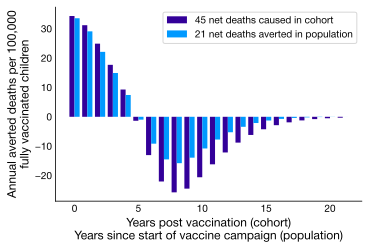

In [2]:
#| label: fig-averted-deaths
#| fig-cap: "Annual averted deaths per 100,000 R21-fully vaccinated five month old children, comparing a multi-cohort population (blue) to a single cohort (purple) and assuming 1 blood infection every 2 years in a perennial setting. The multi-cohort population assumes a vaccine campaign that vaccinates 100% of five month old children each year for 20 years, while the single cohort assumes a one-time vaccination of 100% of five month old children at the start of the study. The total number of deaths averted over the study period is shown in the legend."

fig, ax = cohort_vs_population.plot_single_infection_rate(rc, rp)

[@fig-transmission] compares deaths averted and death efficacy between a multi-cohort population and a single cohort followed for 15 years across a range of blood infection rates. In all cases, the population approach over-estimates averted deaths and efficacy, and is particularly poor at low transmission intensities.

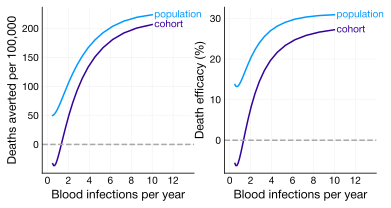

In [3]:
#| label: fig-transmission
#| fig-cap: "Averted deaths per 100,000 R21-fully vaccinated five month old children and death efficacy after 15 years from the start of vaccination across a range of blood infection rates, comparing a multi-cohort population (blue) to a single cohort (purple)."

x = cohort_vs_population.efficacies()
fig, axs = cohort_vs_population.efficacies_plot(x, 1, 1)